In [24]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [25]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [26]:
x_train,y_train = x_train/255, y_train/255
x_test,y_test = x_test/255, y_test/25

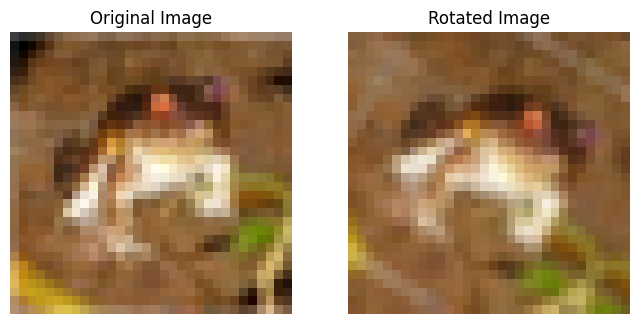

In [27]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Define a RandomRotation layer. Factor determines the range of random rotation angles.
# For example, 0.2 means rotation angles from -20% * 2PI to 20% * 2PI (-72 degrees to 72 degrees).
random_rotation_layer = tf.keras.layers.RandomRotation(factor=0.2, seed=42)

# Select a sample image from x_train to demonstrate
sample_image = x_train[0]

# Apply random rotation to the sample image
rotated_image = random_rotation_layer(tf.expand_dims(sample_image, axis=0))[0]

# Visualize the original and rotated images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rotated_image)
plt.title('Rotated Image')
plt.axis('off')

plt.show()

In [28]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")

Shape of x_train: (50000, 32, 32, 3)
Shape of x_test: (10000, 32, 32, 3)


In [29]:
model = Sequential()

In [30]:
model = Sequential()
model.add(tf.keras.layers.RandomRotation(factor=0.2, seed=42, input_shape=(32, 32, 3))) # Add RandomRotation layer
model.add(Conv2D(32, (3, 3), activation='relu')) # Start with a Conv2D layer
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10, activation='softmax')) # Add a Dense layer for classification (e.g., 10 classes for CIFAR-10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_3               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
training_histories = {}

# OPTIMIZERS

**ADAM**

In [33]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [34]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test) ,verbose =2 )

Epoch 1/5
1563/1563 - 10s - 7ms/step - accuracy: 0.1000 - loss: 0.0014 - val_accuracy: 0.1000 - val_loss: 9.8944e-10
Epoch 2/5
1563/1563 - 9s - 6ms/step - accuracy: 0.1000 - loss: 5.0263e-08 - val_accuracy: 0.1000 - val_loss: 0.0000e+00
Epoch 3/5
1563/1563 - 8s - 5ms/step - accuracy: 0.1000 - loss: 8.8452e-10 - val_accuracy: 0.1000 - val_loss: 0.0000e+00
Epoch 4/5
1563/1563 - 8s - 5ms/step - accuracy: 0.1000 - loss: 8.0346e-10 - val_accuracy: 0.1000 - val_loss: 0.0000e+00
Epoch 5/5
1563/1563 - 9s - 6ms/step - accuracy: 0.1000 - loss: 3.0517e-10 - val_accuracy: 0.1000 - val_loss: 0.0000e+00


In [35]:
training_histories['Adam_Optimizer_History'] = history

ADAMW

In [36]:
model2 = Sequential()
model2.add(tf.keras.layers.RandomRotation(factor=0.2, seed=42, input_shape=(32, 32, 3))) # Add RandomRotation layer
model2.add(Conv2D(32, (3, 3), activation='relu')) # Start with a Conv2D layer
model2.add(MaxPooling2D((2, 2)))
model2.add(Flatten())
model2.add(Dense(64,activation='relu'))
model2.add(Dense(10, activation='softmax')) # Add a Dense layer for classification (e.g., 10 classes for CIFAR-10)

In [37]:
model2.compile(optimizer='adamw',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [38]:
history_adamw = model2.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=2)

training_histories['AdamW_Optimizer_History'] = history_adamw

print("Training history for AdamW optimizer stored.")

Epoch 1/5
1563/1563 - 11s - 7ms/step - accuracy: 0.1000 - loss: 0.0019 - val_accuracy: 0.1000 - val_loss: 2.8014e-09
Epoch 2/5
1563/1563 - 10s - 6ms/step - accuracy: 0.1000 - loss: 2.6991e-08 - val_accuracy: 0.1000 - val_loss: 4.0531e-10
Epoch 3/5
1563/1563 - 9s - 6ms/step - accuracy: 0.1000 - loss: 4.8468e-09 - val_accuracy: 0.1000 - val_loss: 2.2650e-10
Epoch 4/5
1563/1563 - 9s - 6ms/step - accuracy: 0.1000 - loss: 3.2567e-09 - val_accuracy: 0.1000 - val_loss: 8.3446e-11
Epoch 5/5
1563/1563 - 10s - 7ms/step - accuracy: 0.1000 - loss: 1.4734e-09 - val_accuracy: 0.1000 - val_loss: 2.3842e-11
Training history for AdamW optimizer stored.


**SGD**

In [39]:
model3 = Sequential()
model3.add(tf.keras.layers.RandomRotation(factor=0.2, seed=42, input_shape=(32, 32, 3)))
model3.add(Conv2D(32, (3, 3), activation='relu'))
model3.add(MaxPooling2D((2, 2)))
model3.add(Flatten())
model3.add(Dense(64,activation='relu'))
model3.add(Dense(10, activation='softmax'))

In [40]:
model3.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
history_sgd = model3.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=2)

training_histories['SGD_Optimizer_History'] = history_sgd

print("Training history for SGD optimizer stored.")

Epoch 1/5
1563/1563 - 8s - 5ms/step - accuracy: 0.1000 - loss: 0.0069 - val_accuracy: 0.1000 - val_loss: 1.8486e-04
Epoch 2/5
1563/1563 - 7s - 4ms/step - accuracy: 0.1000 - loss: 1.4094e-04 - val_accuracy: 0.1000 - val_loss: 9.1259e-05
Epoch 3/5
1563/1563 - 7s - 5ms/step - accuracy: 0.1000 - loss: 8.0480e-05 - val_accuracy: 0.1000 - val_loss: 6.0502e-05
Epoch 4/5
1563/1563 - 6s - 4ms/step - accuracy: 0.1000 - loss: 5.7275e-05 - val_accuracy: 0.1000 - val_loss: 4.5031e-05
Epoch 5/5
1563/1563 - 7s - 5ms/step - accuracy: 0.1000 - loss: 4.4142e-05 - val_accuracy: 0.1000 - val_loss: 3.5785e-05
Training history for SGD optimizer stored.


## RMSProp



In [42]:
model4 = Sequential()
model4.add(tf.keras.layers.RandomRotation(factor=0.2, seed=42, input_shape=(32, 32, 3)))
model4.add(Conv2D(32, (3, 3), activation='relu'))
model4.add(MaxPooling2D((2, 2)))
model4.add(Flatten())
model4.add(Dense(64,activation='relu'))
model4.add(Dense(10, activation='softmax'))

In [43]:
model4.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [44]:
history_rmsprop = model4.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=2)

training_histories['RMSProp_Optimizer_History'] = history_rmsprop

print("Training history for RMSprop optimizer stored.")

Epoch 1/5
1563/1563 - 9s - 6ms/step - accuracy: 0.1000 - loss: 0.0016 - val_accuracy: 0.1000 - val_loss: 2.2464e-07
Epoch 2/5
1563/1563 - 10s - 6ms/step - accuracy: 0.1000 - loss: 2.6050e-07 - val_accuracy: 0.1000 - val_loss: 9.2298e-08
Epoch 3/5
1563/1563 - 7s - 4ms/step - accuracy: 0.1000 - loss: 1.3528e-07 - val_accuracy: 0.1000 - val_loss: 5.5919e-08
Epoch 4/5
1563/1563 - 8s - 5ms/step - accuracy: 0.1000 - loss: 9.3721e-08 - val_accuracy: 0.1000 - val_loss: 3.9052e-08
Epoch 5/5
1563/1563 - 7s - 4ms/step - accuracy: 0.1000 - loss: 6.9837e-08 - val_accuracy: 0.1000 - val_loss: 2.9706e-08
Training history for RMSprop optimizer stored.


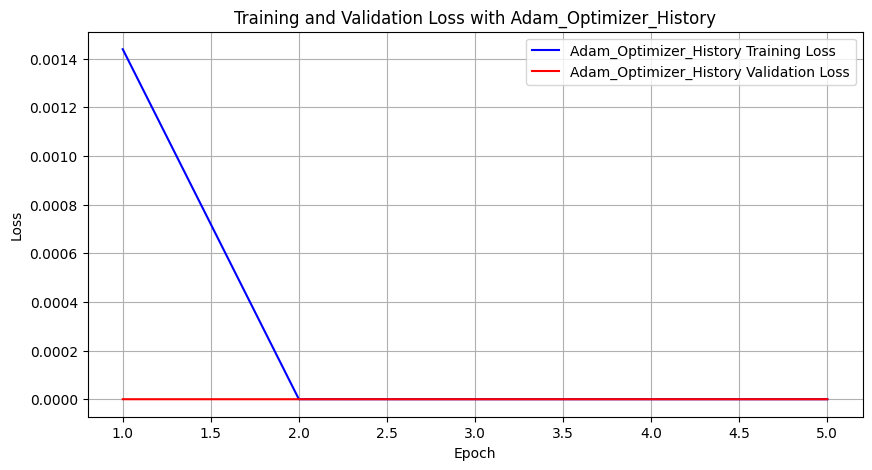

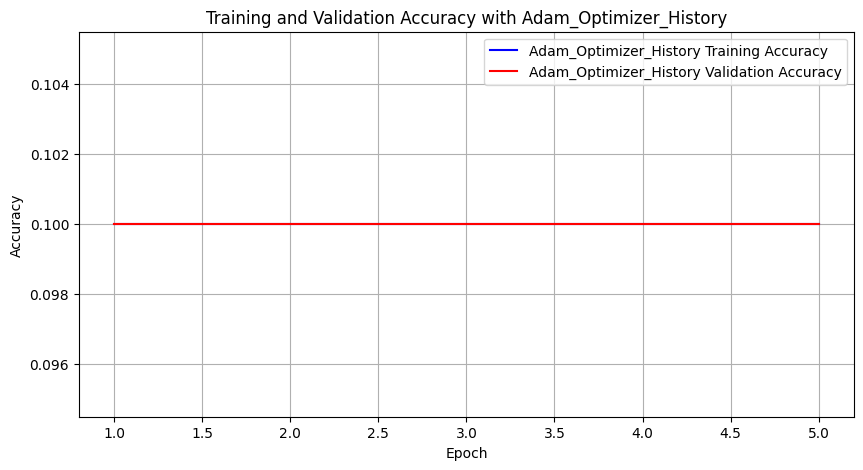

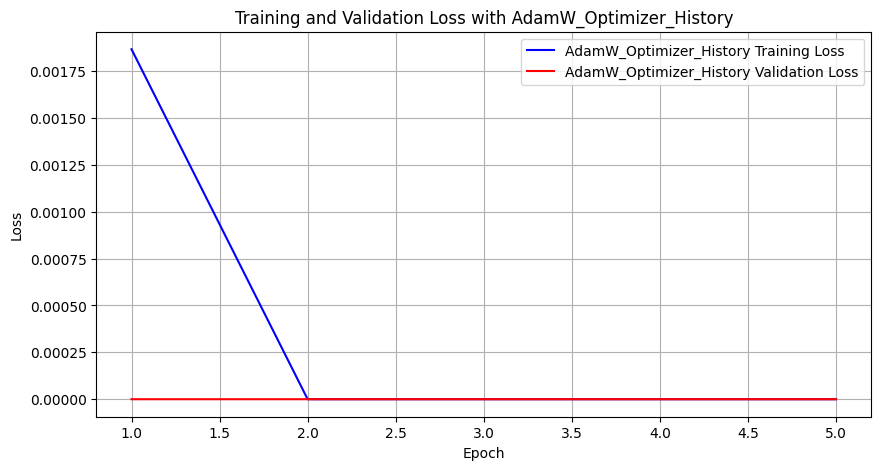

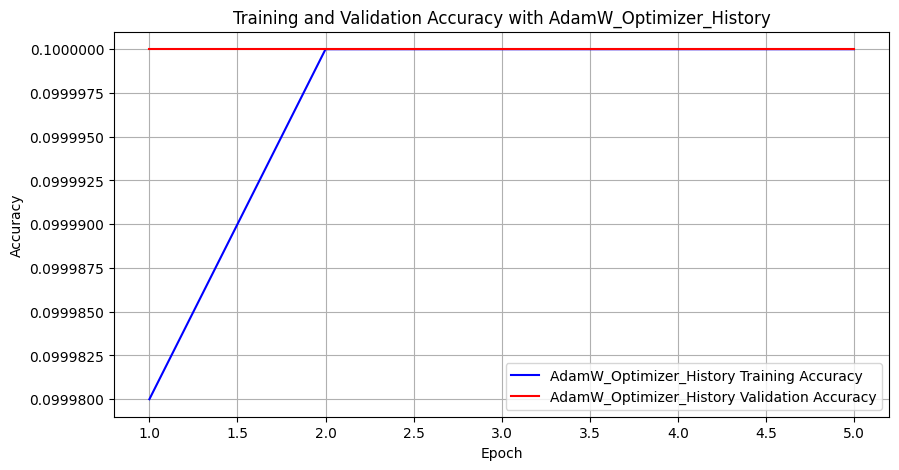

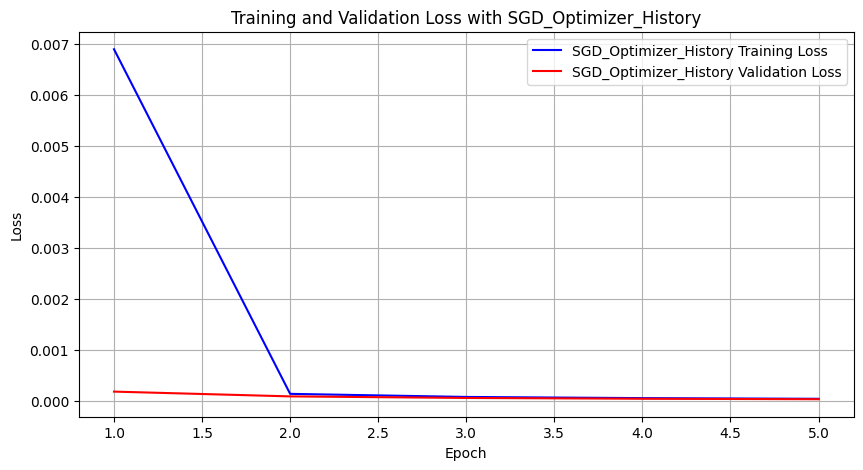

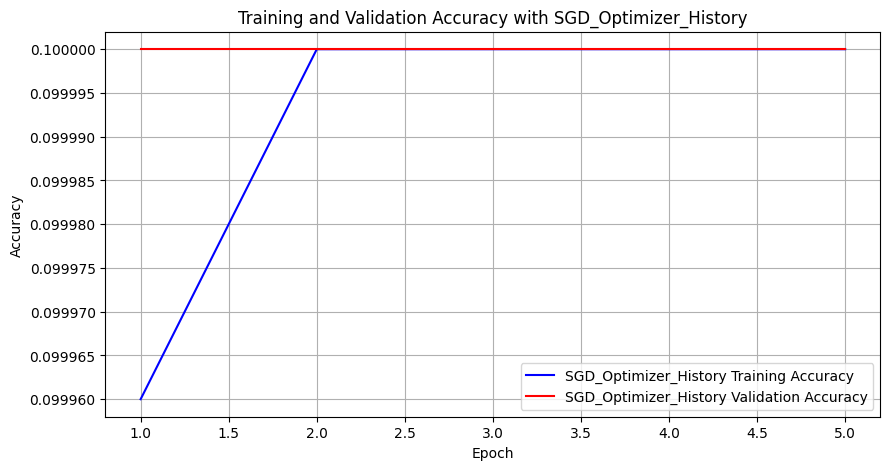

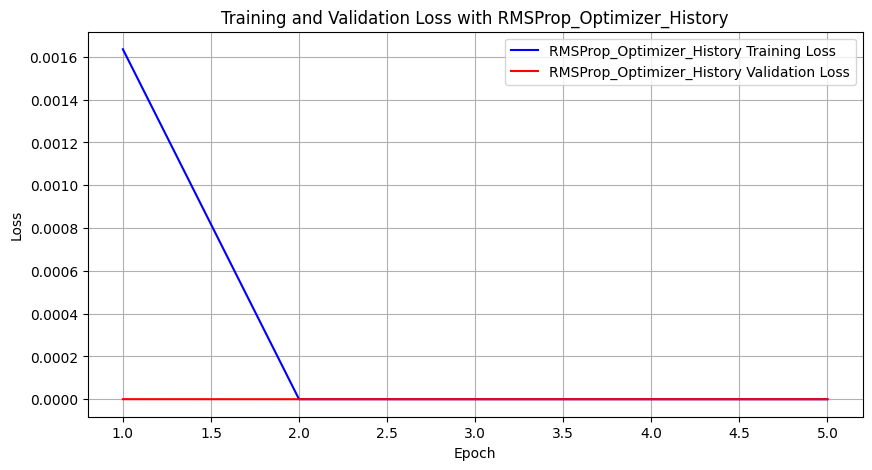

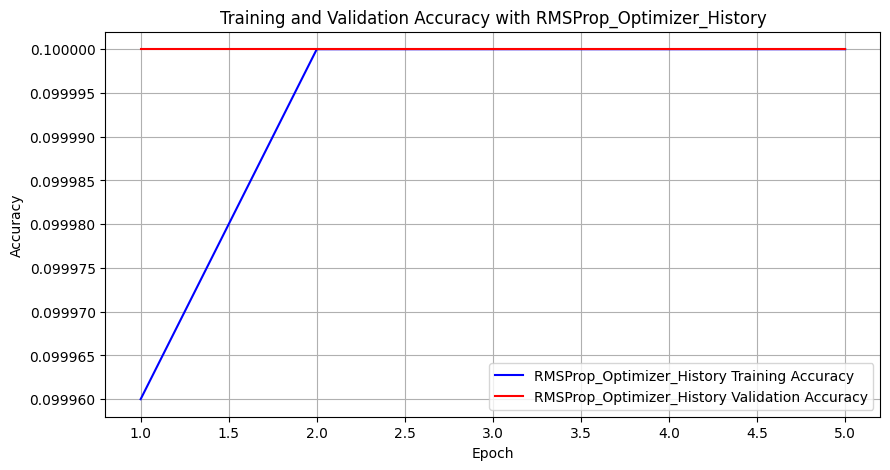

In [45]:
import matplotlib.pyplot as plt

for optimizer_name, history_object in training_histories.items():
    # Extract data from history object
    loss = history_object.history['loss']
    val_loss = history_object.history['val_loss']
    accuracy = history_object.history['accuracy']
    val_accuracy = history_object.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    # Plot Loss Curve
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, 'b', label=f'{optimizer_name} Training Loss')
    plt.plot(epochs, val_loss, 'r', label=f'{optimizer_name} Validation Loss')
    plt.title(f'Training and Validation Loss with {optimizer_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Accuracy Curve
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, accuracy, 'b', label=f'{optimizer_name} Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r', label=f'{optimizer_name} Validation Accuracy')
    plt.title(f'Training and Validation Accuracy with {optimizer_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()